In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

columns = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_largest_3_mean", "texture_largest_3_mean", "perimeter_largest_3_mean", "area_largest_3_mean", "smoothness_largest_3_mean",
    "compactness_largest_3_mean", "concavity_largest_3_mean", "concave_points_largest_3_mean", "symmetry_largest_3_mean", "fractal_dimension_largest_3_mean"
]

df = pd.read_csv("../data_raw/breast_cancer/wdbc.csv", header=None, names=columns)

 # drop id column as it is not useful for analysis
df.drop("id", axis=1, inplace=True)

# convert diagnosis to binary (1 for malignant, 0 for benign)
df["diagnosis"] = df.diagnosis.map({"M": 1, "B": 0}) 

In [3]:
df["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

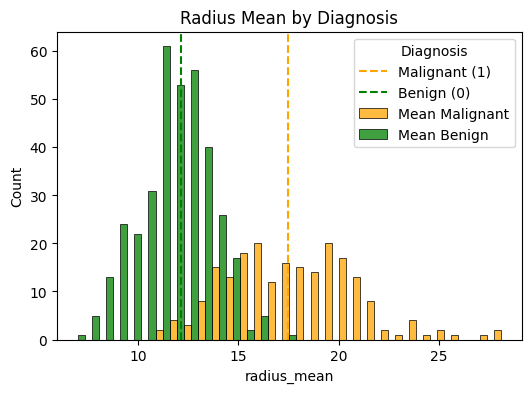

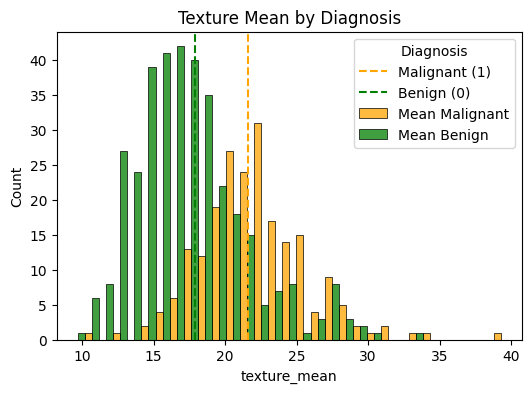

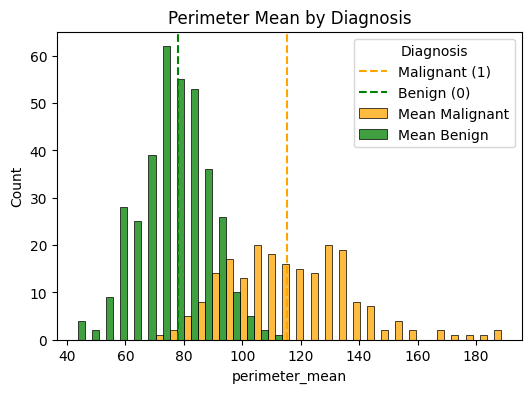

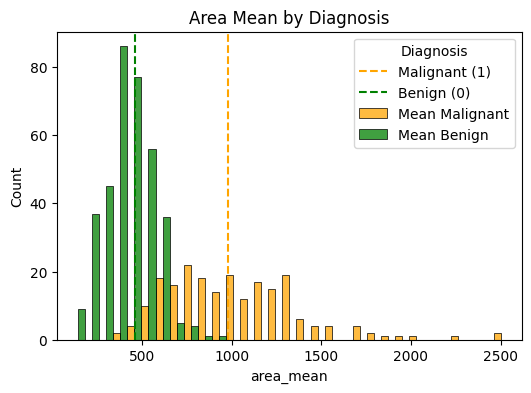

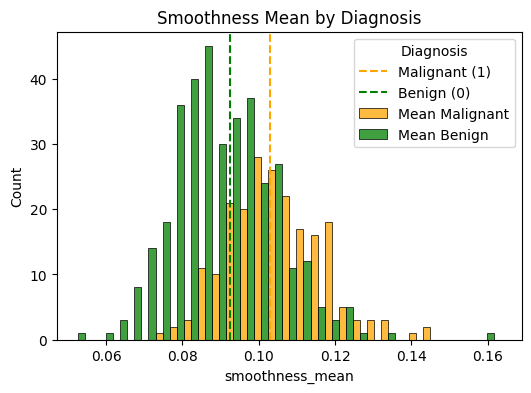

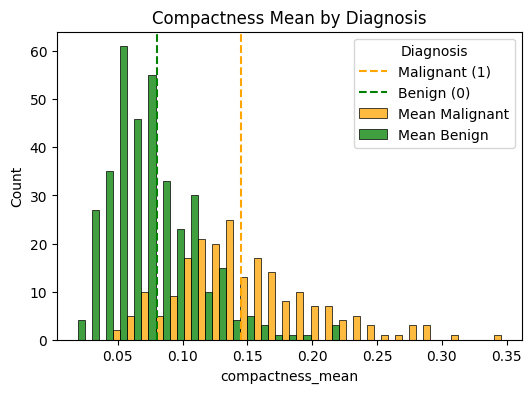

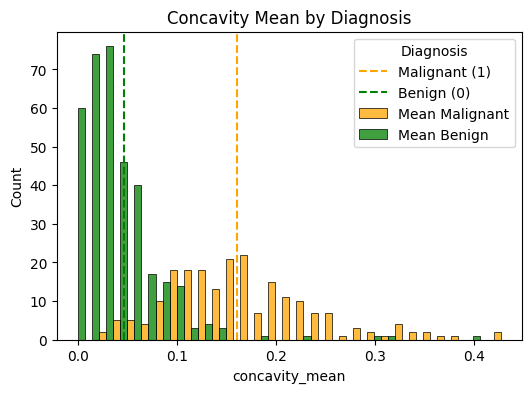

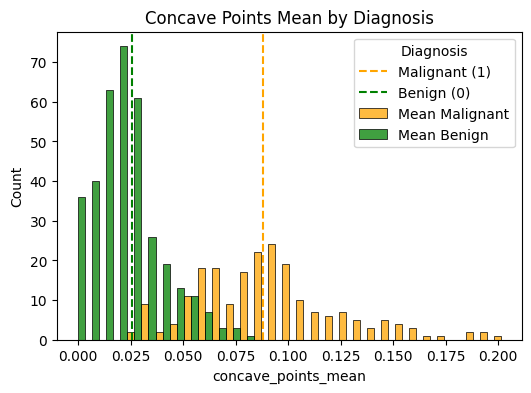

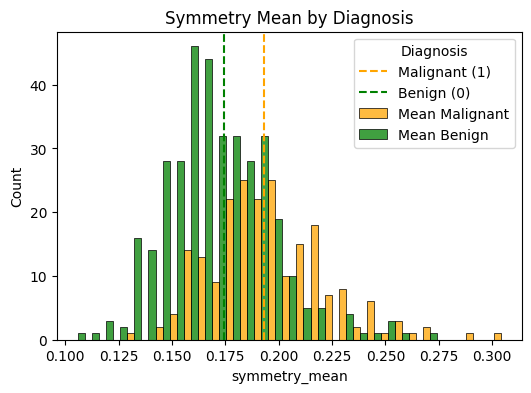

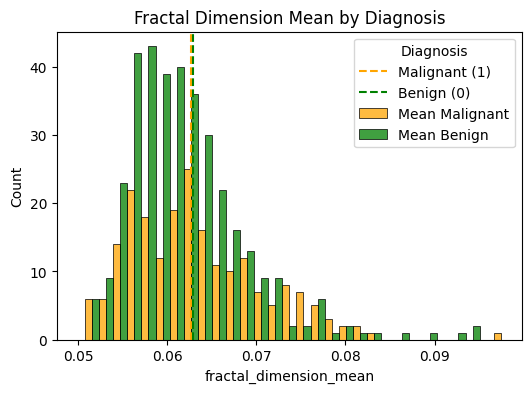

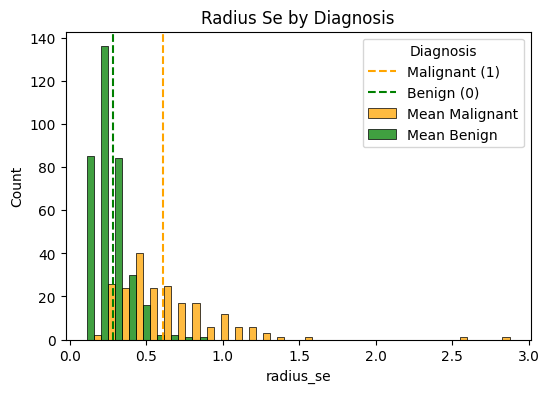

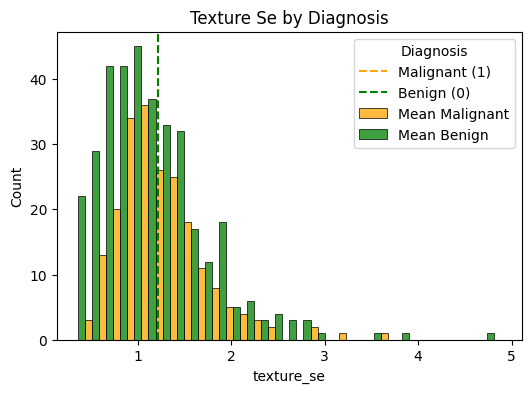

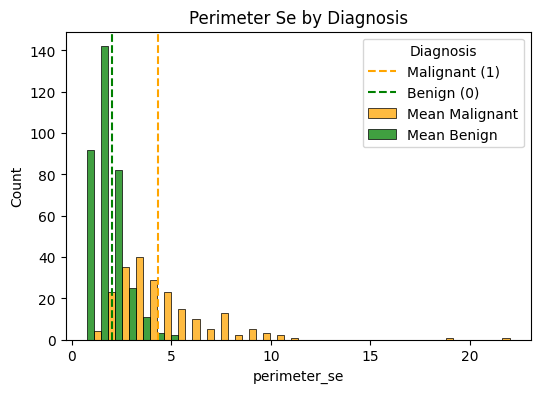

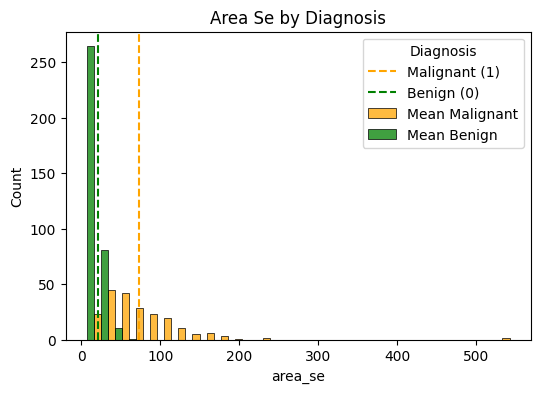

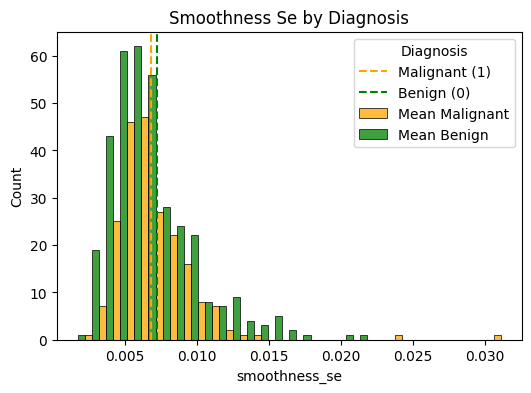

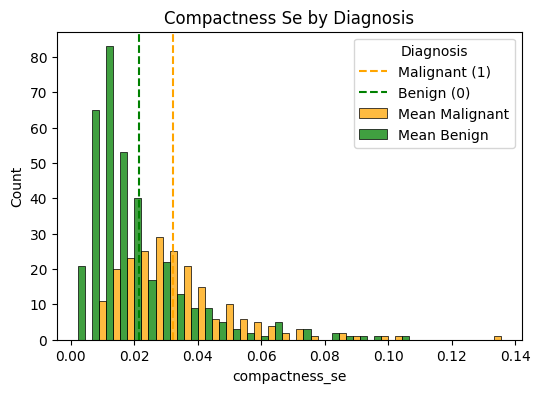

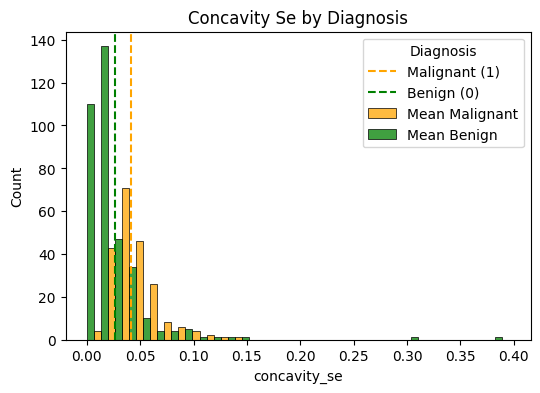

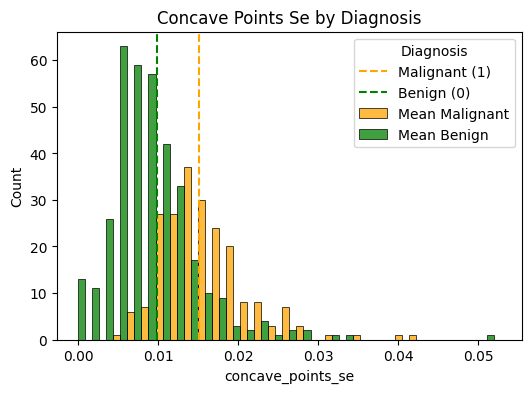

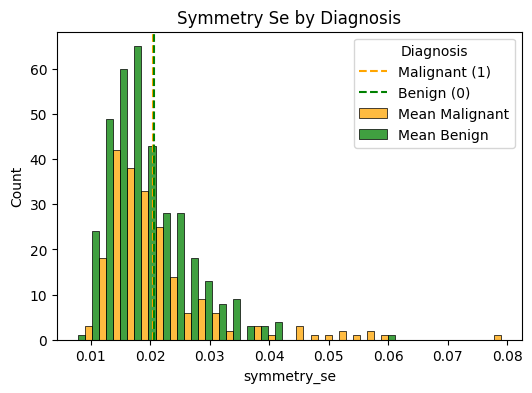

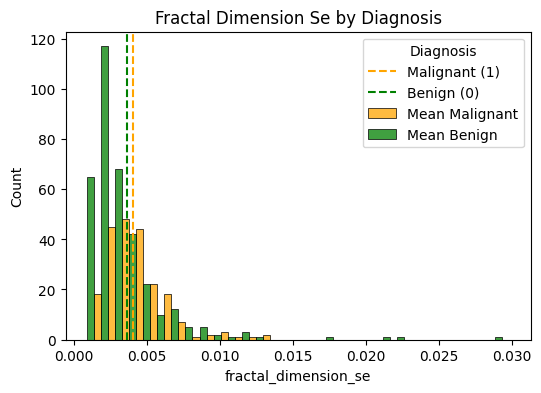

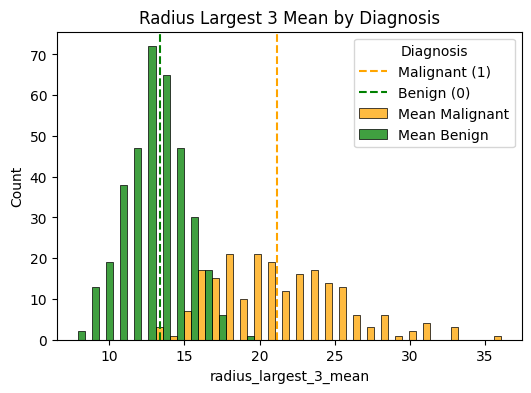

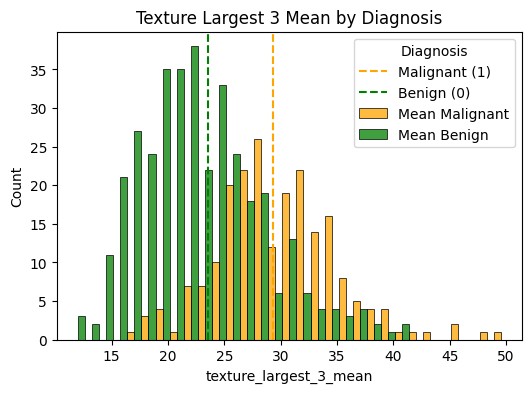

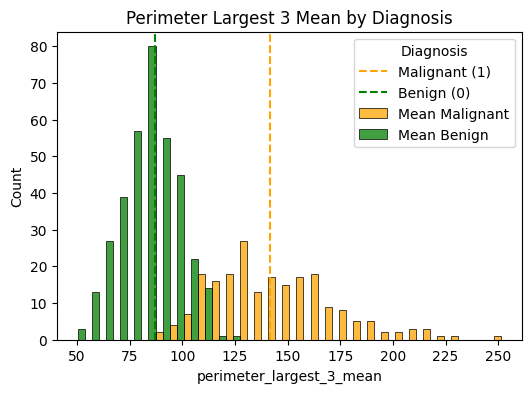

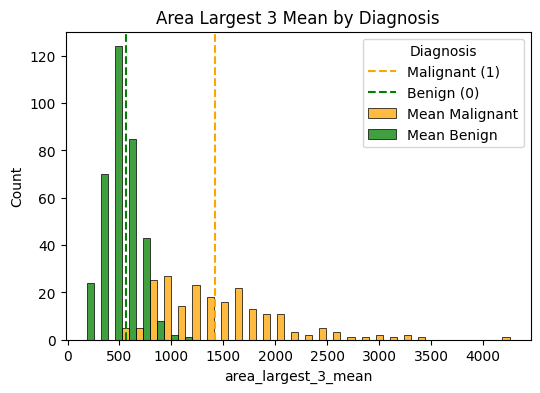

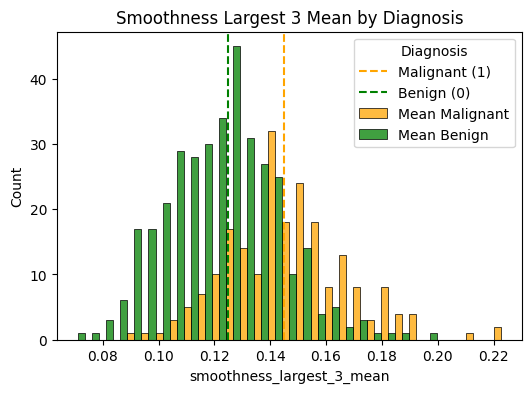

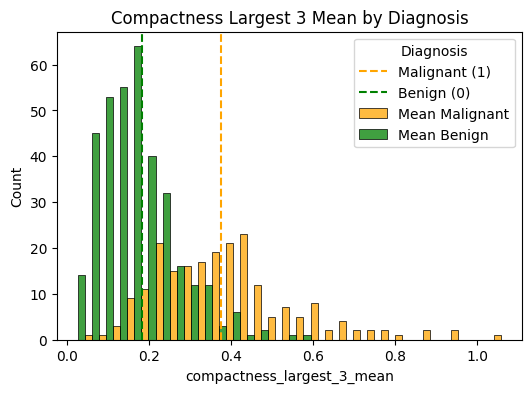

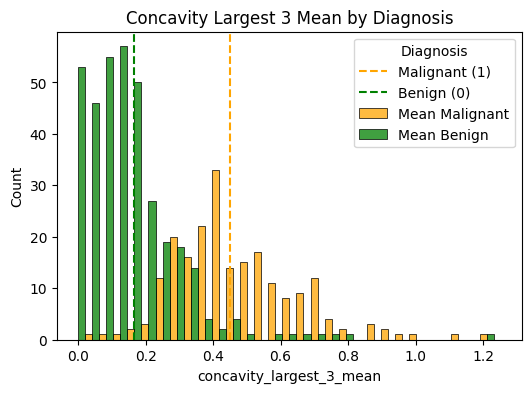

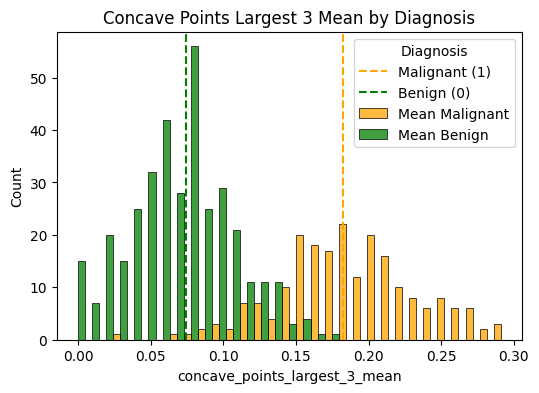

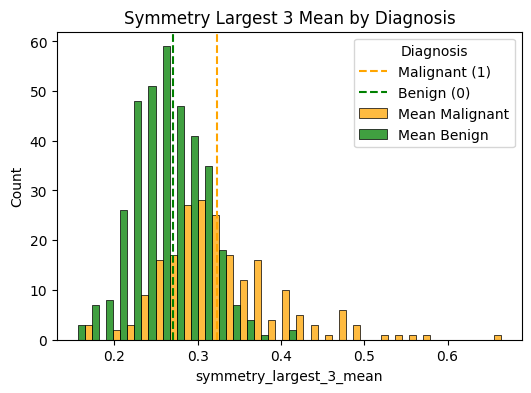

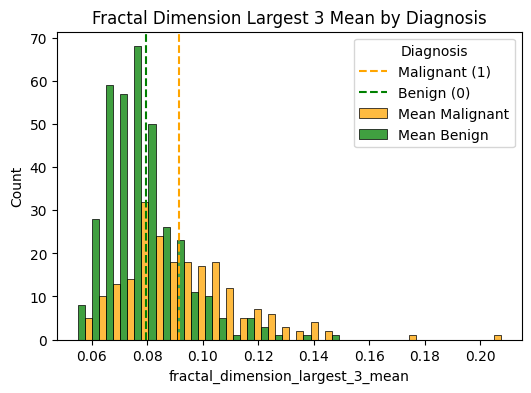

In [7]:
numeric_cols = [x for x in columns if x != "id" and x != "diagnosis"]

def format_col_name(col: str) -> str:
    col = col.replace("_", " ").title()
    return col

for col in numeric_cols:
    plt.figure(figsize=(6,4))

    sns.histplot(
        data=df,
        x=col,
        hue="diagnosis",
        multiple="dodge",
        bins=30,
        palette={0: "green", 1: "orange"} 
    )

    mean_1 = df[df["diagnosis"] == 1][col].mean()
    mean_0 = df[df["diagnosis"] == 0][col].mean()

    plt.axvline(mean_1, color="orange", linestyle="--")
    plt.axvline(mean_0, color="green", linestyle="--")

    plt.legend(
        title="Diagnosis",
        labels=["Malignant (1)", "Benign (0)", "Mean Malignant", "Mean Benign"]
    )

    plt.title(f"{format_col_name(col)} by Diagnosis")
    plt.show()

In [6]:
df.to_csv("../data_cleaned/breast_cancer.csv", index=False)